In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split


Load the data

In [2]:
housing = pd.read_csv("./data/housing.csv")

housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Train set & Test set

In [3]:
train_set, test_set = train_test_split(housing, test_size=.2, random_state=42)

The above is a simple random sampling, but that may not be representative of the data. The house prices are heavily influenced by the median income, so we want to use a _stratified sampling_ strategy besed on the median income.

**NOTE**: we need to transform the median income to a categorical feature in order to do the stratified sampling. We apply a _capping_ (or _clipping_) at 5.0 to limit the number of categories.

In [4]:
income_cat = pd.Series(
    np.ceil(housing["median_income"] / 1.5),
    index=housing.index
)
housing["income_cat"] = income_cat.clip(upper=5)

<Axes: >

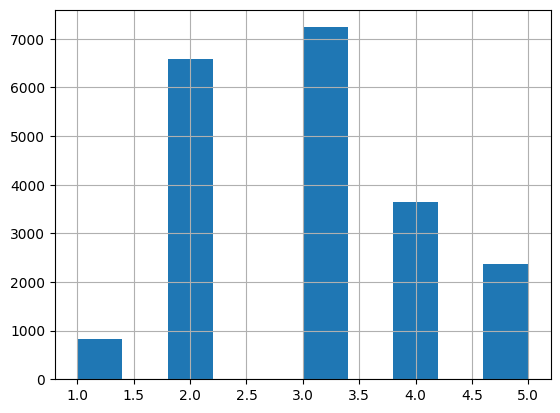

In [5]:
housing["income_cat"].hist()

We can now do the split:

In [ ]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=.2, random_state=42)

train_idx, test_idx = next(splitter.split(housing, housing["income_cat"]))

train_set = housing.loc[train_idx].drop(["income_cat"], axis=1)
test_set = housing.loc[test_idx].drop(["income_cat"], axis=1)

We can obtain the same effect via a higher-lvl API provided by `sklearn` lib:

In [7]:
train_set, test_set = train_test_split(
    housing,
    test_size=.2,
    random_state=42,
    stratify=housing["income_cat"]
)

We might want to add new features to the dataset (derived from the current feature set) that can capture interesting aspects of the domain problem.

In [14]:
# avg no. of rooms per household
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]

# avg no. of bedrooms per household
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

# avg no. of people per household
housing["population_per_household"] = housing["population"] / housing["households"]

In [15]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_household,bedrooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5.0,6.984127,1.023810,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5.0,6.238137,0.971880,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5.0,8.288136,1.073446,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4.0,5.817352,1.073059,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3.0,6.281853,1.081081,2.181467,0.172096


And we can look at the target to feature correlations to see if we got something interesting.

Seems like the `bedrooms_per_room` provides quite a strong signal. The correlation value is bigger when compared with the `total_rooms` feature. Explanation: large amounts of non-bedroom space is a sign of high-value / luxury.

In [16]:
housing.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
income_cat                  0.643892
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
bedrooms_per_household     -0.046739
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64